EDA on fer2013 dataset

In [5]:
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np

angry: 4953 images
disgust: 547 images
fear: 5121 images
happy: 8989 images
neutral: 6198 images
sad: 6077 images
surprise: 4002 images


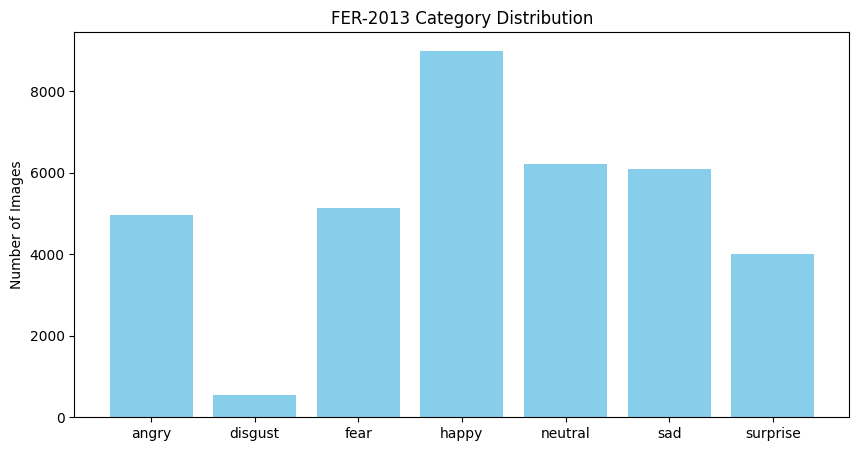

In [6]:
dataset = torch.load("data/processed/fer2013_tensors.pt")

labels = dataset['y'] 
class_to_idx = dataset['class_to_idx']

idx_to_class = {v: k for k, v in class_to_idx.items()}

unique_labels, counts = torch.unique(labels, return_counts=True)

class_names = [idx_to_class[int(label)] for label in unique_labels]
counts_list = counts.tolist()

for name, count in zip(class_names, counts_list):
    print(f"{name}: {count} images")

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts_list, color='skyblue')
plt.title("FER-2013 Category Distribution")
plt.ylabel("Number of Images")
plt.show()

Original images: 35887
Cleaned images: 35872 (Filtered 15 junk images)


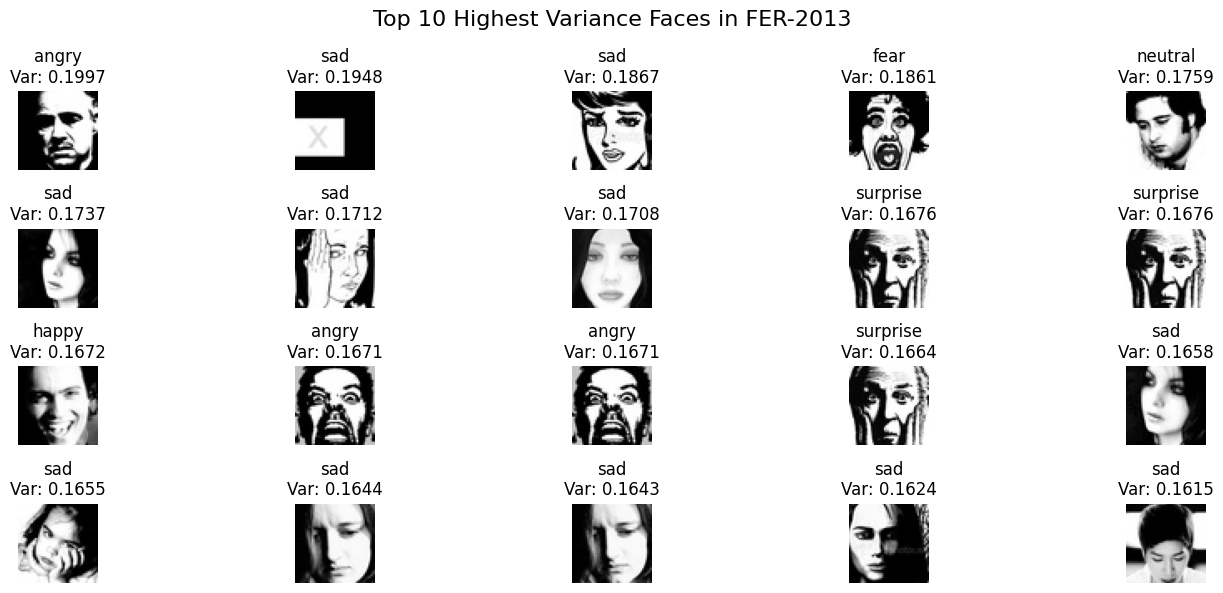

In [ ]:

data_dict = torch.load("data/processed/fer2013_tensors.pt")

images = data_dict['X']
labels = data_dict['y']
class_to_idx = data_dict['class_to_idx']

idx_to_class = {v: k for k, v in class_to_idx.items()}

dim_to_var = (1, 2, 3) if images.dim() == 4 else (1, 2)
variances = torch.var(images, dim=dim_to_var)
threshold = 100.0 / (255.0 ** 2)
valid_mask = variances > threshold

clean_images = images[valid_mask]
clean_labels = labels[valid_mask]
clean_variances = variances[valid_mask]

print(f"Original images: {len(images)}")
print(f"Cleaned images: {len(clean_images)} (Filtered {len(images) - len(clean_images)} junk images)")

num_samples = 20
top_variances, top_indices = torch.topk(variances, k=num_samples)

fig, axes = plt.subplots(4, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(top_indices):
    img_tensor = images[idx]
    label_idx = int(labels[idx].item())
    var_value = top_variances[i].item()

    img_display = img_tensor.squeeze().numpy()
    
    axes[i].imshow(img_display, cmap='gray', vmin=0, vmax=1) 
    
    axes[i].set_title(f"{idx_to_class[label_idx]}\nVar: {var_value:.4f}")
    axes[i].axis('off')

plt.suptitle("Top 10 Highest Variance Faces in FER-2013", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Dataset size before deduplication: {len(clean_images)}")

flattened_images = clean_images.view(clean_images.shape[0], -1).numpy()
_, unique_indices = np.unique(flattened_images, axis=0, return_index=True)

unique_indices = torch.from_numpy(unique_indices)

deduped_images = clean_images[unique_indices]
deduped_labels = clean_labels[unique_indices]

print(f"Dataset size after deduplication: {len(deduped_images)}")
print(f"Removed {len(clean_images) - len(deduped_images)} exact duplicate images.")

Dataset size before deduplication: 35872
Dataset size after deduplication: 34030
Removed 1842 exact duplicate images.


Standardizing lighting across the dataset...
Lighting standardization complete.


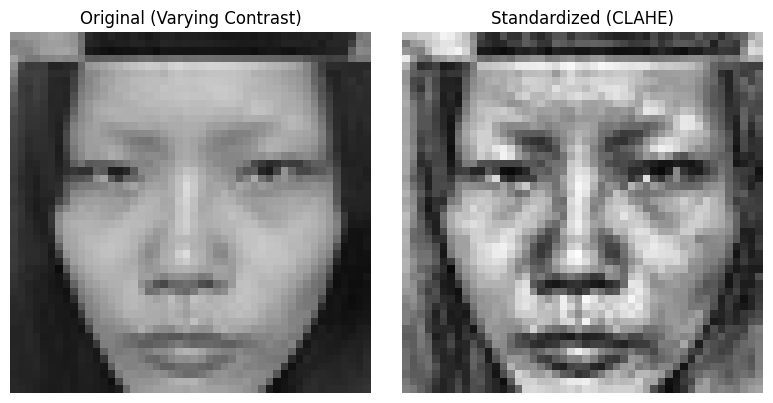

In [ ]:
print("Standardizing lighting across the dataset...")

images_np = deduped_images.squeeze().numpy()  # Shape becomes [N, 48, 48]

images_uint8 = (images_np * 255.0).astype(np.uint8)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

equalized_images_list = []
for img in images_uint8:
    eq_img = clahe.apply(img)
    equalized_images_list.append(eq_img)

equalized_np = np.array(equalized_images_list)
final_images_tensor = torch.tensor(equalized_np, dtype=torch.float32).unsqueeze(1) / 255.0

print("Lighting standardization complete.")

idx = torch.randint(0, len(deduped_images), (1,)).item()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(images_np[idx], cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Original (Varying Contrast)")
axes[0].axis('off')

axes[1].imshow(final_images_tensor[idx].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Standardized (CLAHE)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Calculating post-standardization variances...


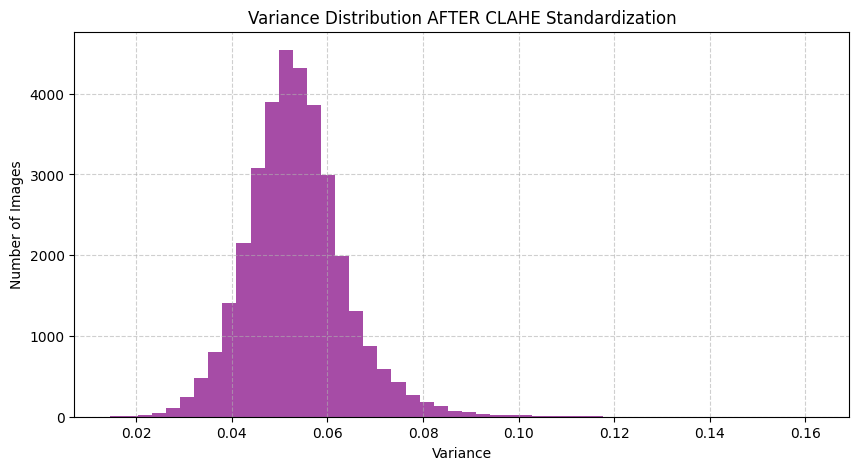

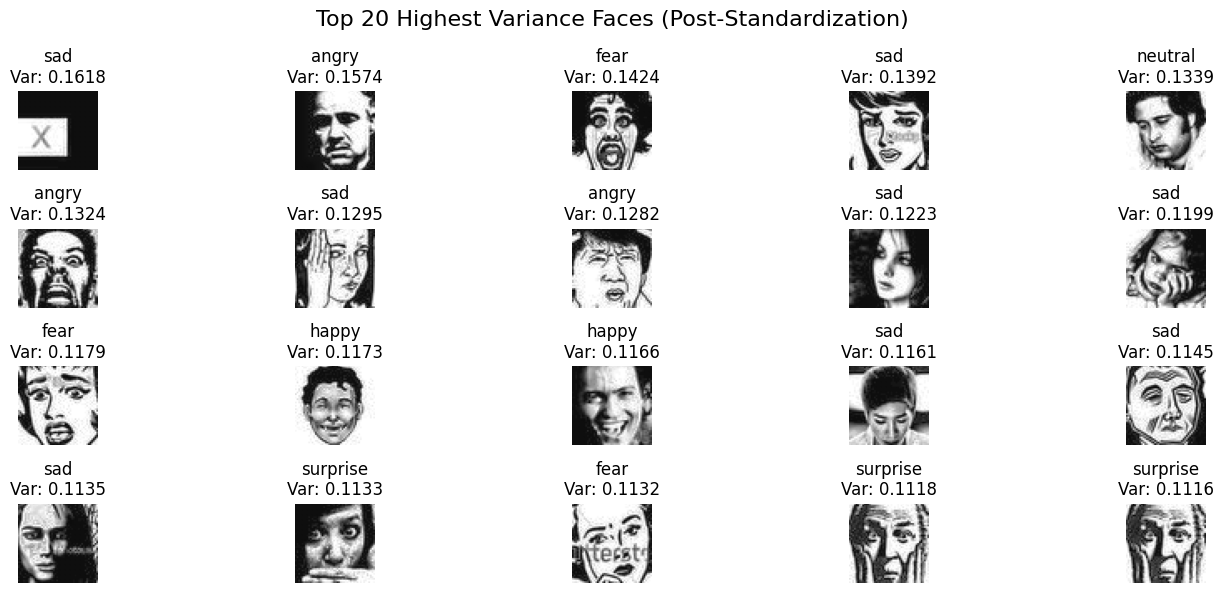

In [ ]:
print("Calculating post-standardization variances...")

new_variances = torch.var(final_images_tensor, dim=(1, 2, 3))

plt.figure(figsize=(10, 5))
plt.hist(new_variances.numpy(), bins=50, color='purple', alpha=0.7)
plt.title("Variance Distribution AFTER CLAHE Standardization")
plt.xlabel("Variance")
plt.ylabel("Number of Images")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

num_samples = 20
top_variances, top_indices = torch.topk(new_variances, k=num_samples, largest = True)

fig, axes = plt.subplots(4, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(top_indices):
    img_tensor = final_images_tensor[idx]
    label_idx = int(deduped_labels[idx].item())
    var_value = top_variances[i].item()
    
    img_display = img_tensor.squeeze().numpy()
    
    axes[i].imshow(img_display, cmap='gray', vmin=0, vmax=1) 
    axes[i].set_title(f"{idx_to_class[label_idx]}\nVar: {var_value:.4f}")
    axes[i].axis('off')

plt.suptitle("Top 20 Highest Variance Faces (Post-Standardization)", fontsize=16)
plt.tight_layout()
plt.show()

Scanning edge densities...


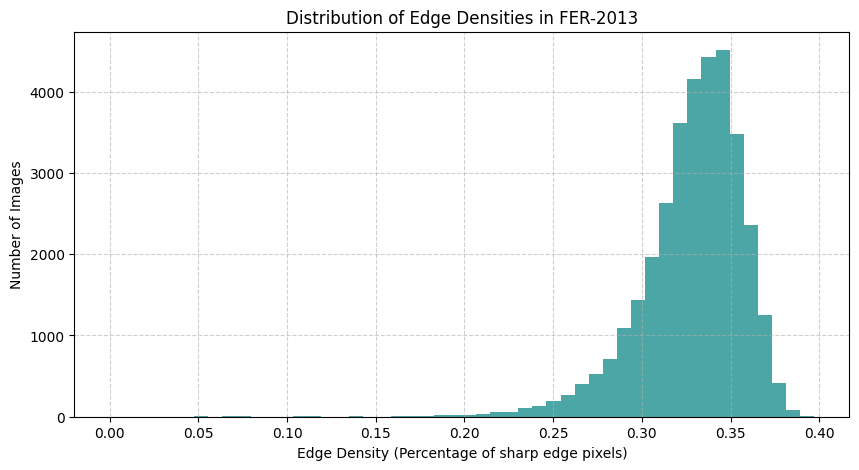

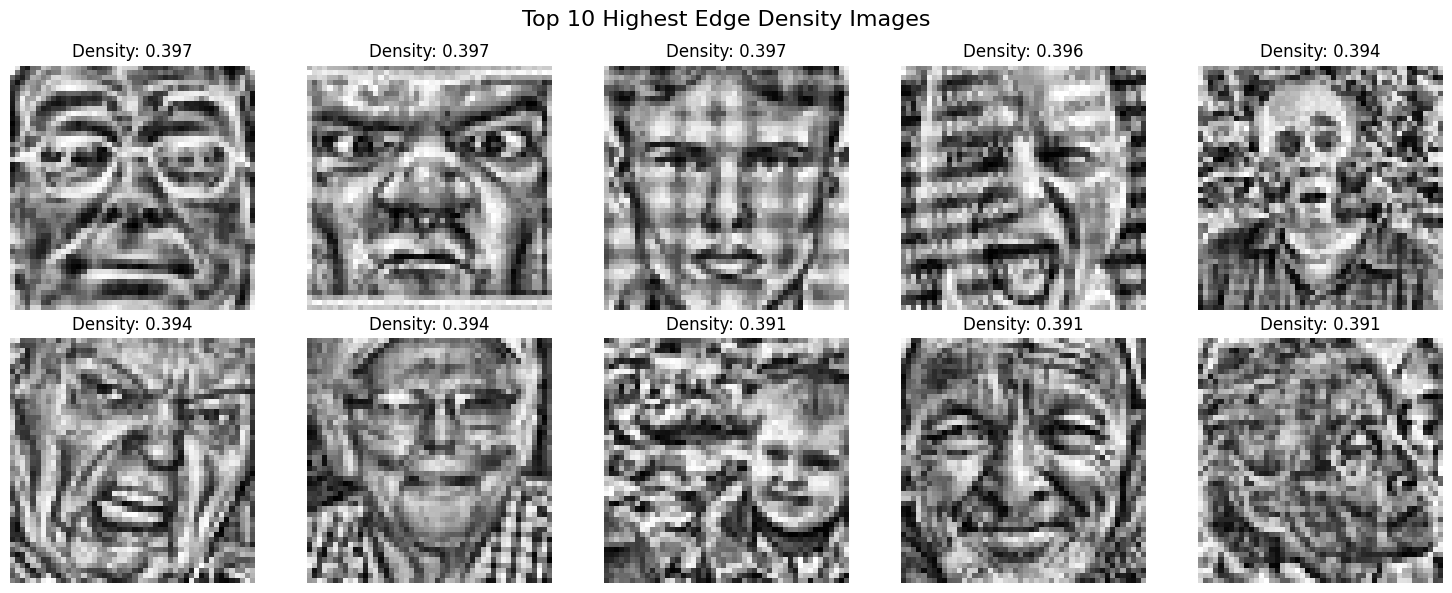

In [ ]:
print("Scanning edge densities...")

edge_densities = []

for idx in range(len(final_images_tensor)):
    img_tensor = final_images_tensor[idx].squeeze()
    img_uint8 = (img_tensor.numpy() * 255.0).astype(np.uint8)
    
    edges = cv2.Canny(img_uint8, threshold1=100, threshold2=200)
    
    density = np.sum(edges > 0) / (48 * 48)
    edge_densities.append(density)

edge_densities = np.array(edge_densities)

plt.figure(figsize=(10, 5))
plt.hist(edge_densities, bins=50, color='teal', alpha=0.7)
plt.title("Distribution of Edge Densities in FER-2013")
plt.xlabel("Edge Density (Percentage of sharp edge pixels)")
plt.ylabel("Number of Images")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

top_indices = np.argsort(edge_densities)[-10:][::-1]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(top_indices):
    img = (final_images_tensor[idx].squeeze().numpy() * 255).astype(np.uint8)
    density_val = edge_densities[idx]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Density: {density_val:.3f}")
    axes[i].axis('off')

plt.suptitle("Top 10 Highest Edge Density Images", fontsize=16)
plt.tight_layout()
plt.show()

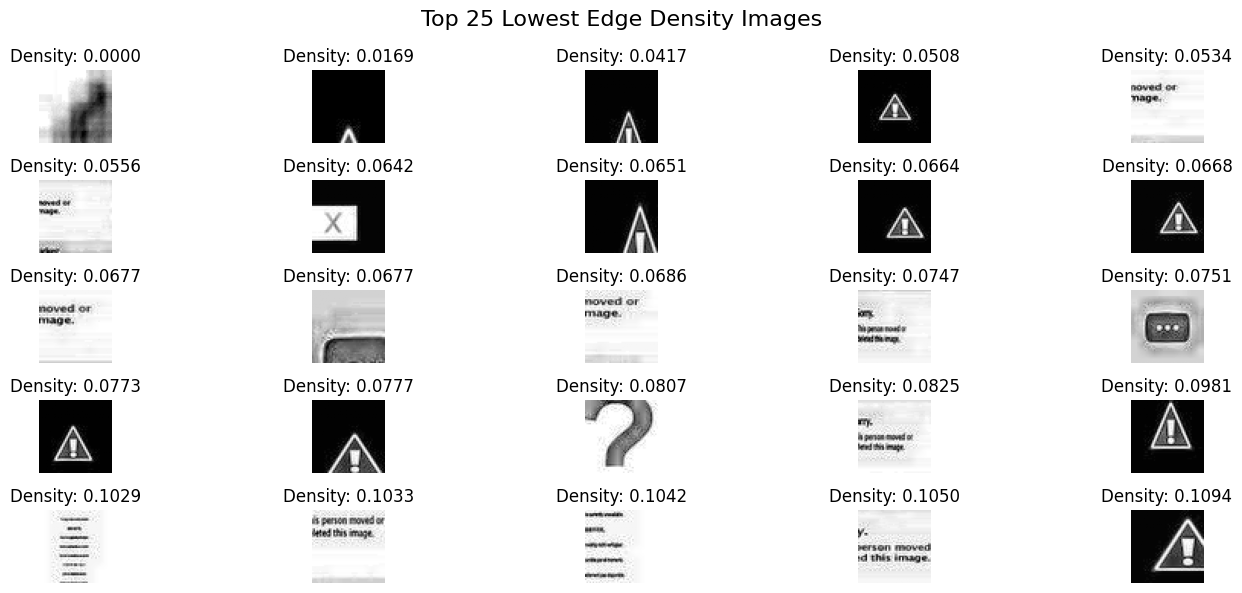

In [ ]:
bottom_indices = np.argsort(edge_densities)[:25]

fig, axes = plt.subplots(5, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(bottom_indices):
    img = (final_images_tensor[idx].squeeze().numpy() * 255).astype(np.uint8)
    density_val = edge_densities[idx]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Density: {density_val:.4f}")
    axes[i].axis('off')

plt.suptitle("Top 25 Lowest Edge Density Images", fontsize=16)
plt.tight_layout()
plt.show()

Found 2 images with an edge density between 0.15 and 0.16


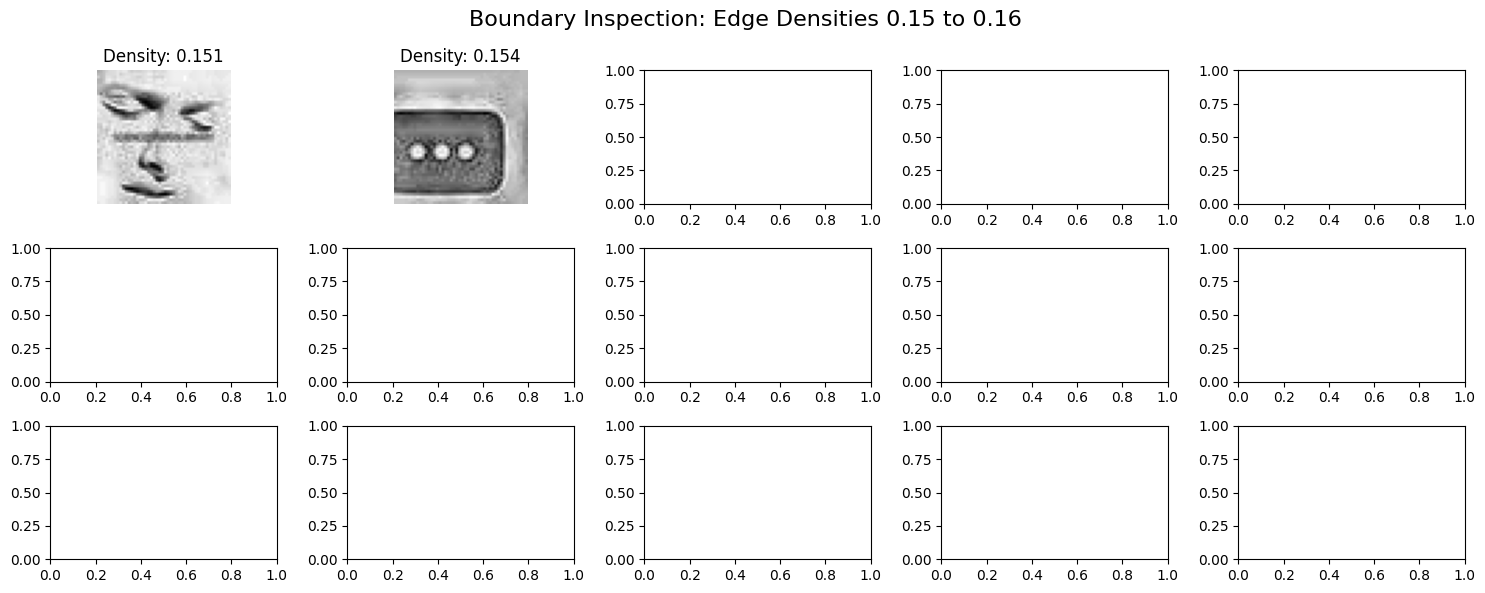

In [ ]:
lower_bound = 0.15
upper_bound = 0.16

boundary_indices = np.where((edge_densities >= lower_bound) & (edge_densities <= upper_bound))[0]
print(f"Found {len(boundary_indices)} images with an edge density between {lower_bound} and {upper_bound}")

sample_indices = np.random.choice(boundary_indices, size=min(15, len(boundary_indices)), replace=False)

fig, axes = plt.subplots(3, 5, figsize=(15, 6))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img = (final_images_tensor[idx].squeeze().numpy() * 255).astype(np.uint8)
    density_val = edge_densities[idx]
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Density: {density_val:.3f}")
    axes[i].axis('off')

plt.suptitle(f"Boundary Inspection: Edge Densities {lower_bound} to {upper_bound}", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
final_edge_threshold = 0.16

keep_mask = edge_densities >= final_edge_threshold

keep_mask_torch = torch.from_numpy(keep_mask)

final_images = final_images_tensor[keep_mask_torch]
final_labels = deduped_labels[keep_mask_torch]

print(f"Dataset size before final edge filter: {len(final_images_tensor)}")
print(f"Dataset size after edge filter: {len(final_images)}")
print(f"Removed {len(final_images_tensor) - len(final_images)} low-density junk images.")

Dataset size before final edge filter: 34030
Dataset size after edge filter: 33993
Removed 37 low-density junk images.


angry: 4735 images
disgust: 459 images
fear: 4819 images
happy: 8791 images
neutral: 6040 images
sad: 5909 images
surprise: 3240 images


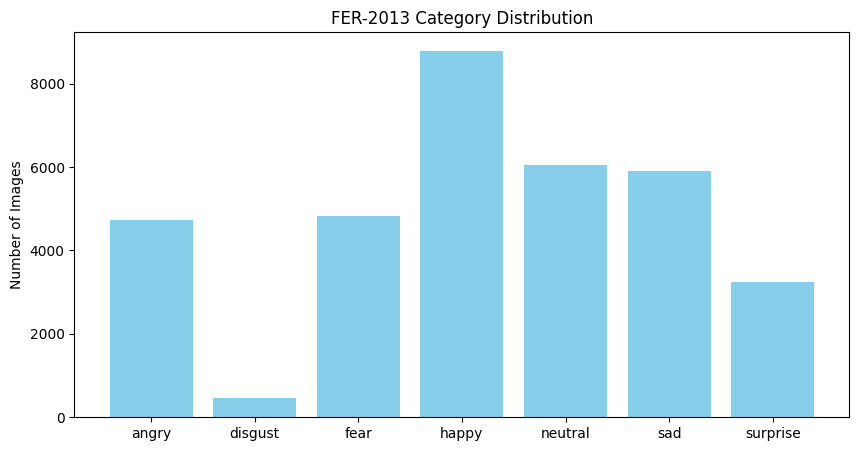

In [15]:
class_to_idx = dataset['class_to_idx']

idx_to_class = {v: k for k, v in class_to_idx.items()}

unique_labels, counts = torch.unique(final_labels, return_counts=True)

class_names = [idx_to_class[int(label)] for label in unique_labels]
counts_list = counts.tolist()

for name, count in zip(class_names, counts_list):
    print(f"{name}: {count} images")

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts_list, color='skyblue')
plt.title("FER-2013 Category Distribution")
plt.ylabel("Number of Images")
plt.show()

In [ ]:
disgust_idx = class_to_idx['disgust']

keep_mask = final_labels != disgust_idx

filtered_images = final_images[keep_mask]
filtered_labels = final_labels[keep_mask]

print(f"Original dataset size: {len(final_images)}")
print(f"New dataset size: {len(filtered_images)}")
print(f"Removed {len(final_images) - len(filtered_images)} 'disgust' images.")

new_class_to_idx = {}
new_label_counter = 0

remapped_labels = filtered_labels.clone()

for class_name, old_idx in class_to_idx.items():
    if class_name == 'disgust':
        continue
        
    new_class_to_idx[class_name] = new_label_counter
    
    remapped_labels[filtered_labels == old_idx] = new_label_counter
    
    new_label_counter += 1

print("\nOld mapping:", class_to_idx)
print("New mapping:", new_class_to_idx)

final_images = filtered_images
final_labels = remapped_labels
class_to_idx = new_class_to_idx

Original dataset size: 33993
New dataset size: 33534
Removed 459 'disgust' images.

Old mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
New mapping: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


In [ ]:
print(f"X shape: {final_images.shape}")
print(f"y shape: {final_labels.shape}")

assert final_images.shape[0] == final_labels.shape[0], "Mismatch between images and labels!"

X shape: torch.Size([33534, 1, 48, 48])
y shape: torch.Size([33534])


In [22]:
from src import preprocess_data as pre

data = {
    "X": final_images,
    "y": final_labels,
    "class_to_idx": class_to_idx
    }
torch.save(data, "data/processed/final_fer2013_tensors.pt")

pre.create_train_test_split(data, "data/processed/final_fer2013_train_test.pt")

saved train/test split to data/processed/final_fer2013_train_test.pt
